## Part 1 - Wafer Defect Analysis

This scenario follows a binomial distribution because each batch contains a fixed number of 25 wafers, each wafer has two possible outcomes (defective or not defective), the probability of a critical defect remains constant at 0.03, and the outcomes are assumed to be independent.

The analysis calculates the probabilities of finding exactly 0, 1, 2, and 3 defective wafers, the probability of finding more than 2 defects, the expected number of defects per batch, and the standard deviation. The expected daily number of defective wafers is also calculated for 100 batches.

--- Probability of exactly k defective wafers ---
P(X = 0) = 0.4670
P(X = 1) = 0.3611
P(X = 2) = 0.1340
P(X = 3) = 0.0318

P(more than 2 defective wafers) = 0.038
Expected defects per batch     = 0.75
Standard deviation              = 0.8529
Expected defects in 100 batches = 75.0


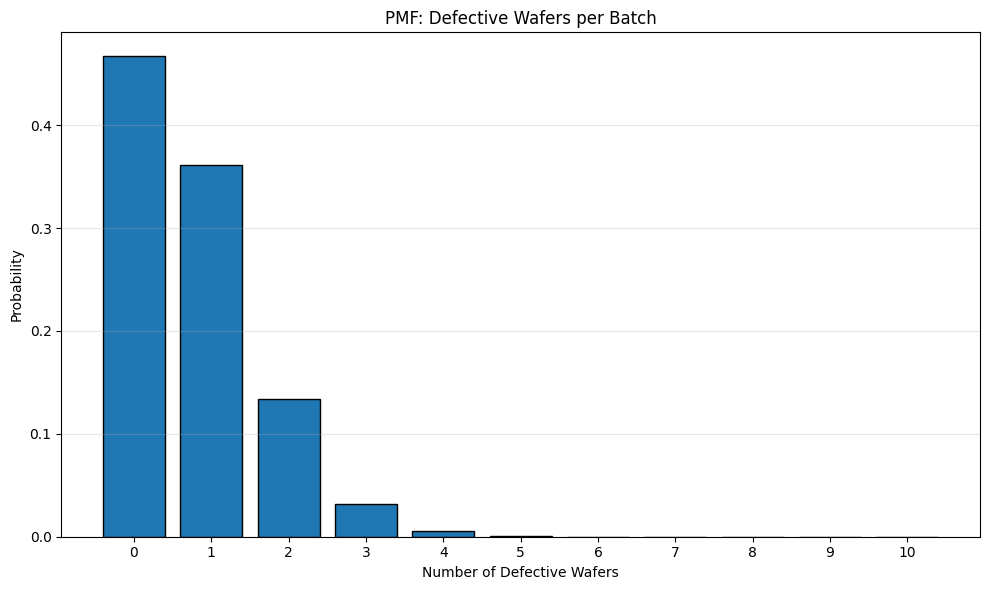


Saved part1_visualization.png


In [ ]:
# Part 1 - Wafer Defect Analysis

# import required libraries
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# problem parameters
batch_size = 25
defect_probability = 0.03

n = batch_size
p = defect_probability

print("--- Probability of exactly k defective wafers ---")

# calculate probability of exactly 0, 1, 2, and 3 defects
for k in range(4):
    probability = binom.pmf(k, n, p)
    print(f"P(X = {k}) = {probability:.4f}")

# probability of more than 2 defective wafers
prob_more_than_2 = binom.sf(2, n, p)

# expected value and standard deviation
expected_defects = n * p
standard_deviation = np.sqrt(n * p * (1 - p))

# expected defects in 100 batches
expected_daily_defects = expected_defects * 100

print("\nP(more than 2 defective wafers) =", round(prob_more_than_2, 4))
print("Expected defects per batch     =", round(expected_defects, 4))
print("Standard deviation              =", round(standard_deviation, 4))
print("Expected defects in 100 batches =", round(expected_daily_defects, 2))

# PMF from 0 to 10 defective wafers
x = np.arange(0, 11)
pmf = binom.pmf(x, n, p)

plt.figure(figsize=(10, 6))
plt.bar(x, pmf, edgecolor="black")

plt.title("PMF: Defective Wafers per Batch")
plt.xlabel("Number of Defective Wafers")
plt.ylabel("Probability")
plt.xticks(x)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("part1_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved part1_visualization.png")

### Part 1 Interpretation

The most likely outcomes are zero or one defective wafer per batch. The probability of finding more than two defective wafers is only about 3.80%, which indicates that batches containing several critical defects should be relatively uncommon.

The expected number of defective wafers is 0.75 per batch, with a standard deviation of approximately 0.853 wafers. If 100 batches are produced in one day, approximately 75 defective wafers would be expected on average.

## Part 2 - Clean Room Particle Detection

This scenario follows a Poisson distribution because contamination events occur randomly and independently over a fixed period of time at an average rate of 2.5 events per hour.

The historical contamination data has an observed mean of 2.433 events per hour, which is reasonably close to the stated model rate of 2.5 events per hour. The Poisson distribution is used to calculate contamination probabilities for one-hour, 30-minute, and four-hour periods.

Historical average rate: 2.433

--- Probability of exactly k events in 1 hour ---
P(X = 0) = 0.0821
P(X = 1) = 0.2052
P(X = 2) = 0.2565
P(X = 3) = 0.2138
P(X = 4) = 0.1336
P(X = 5) = 0.0668

P(more than 4 events in 1 hour) = 0.1088
P(0 events in 30 minutes)       = 0.2865
P(>1 hr cleaning in 4-hr shift) = 0.9707

Saved part2_visualization.png


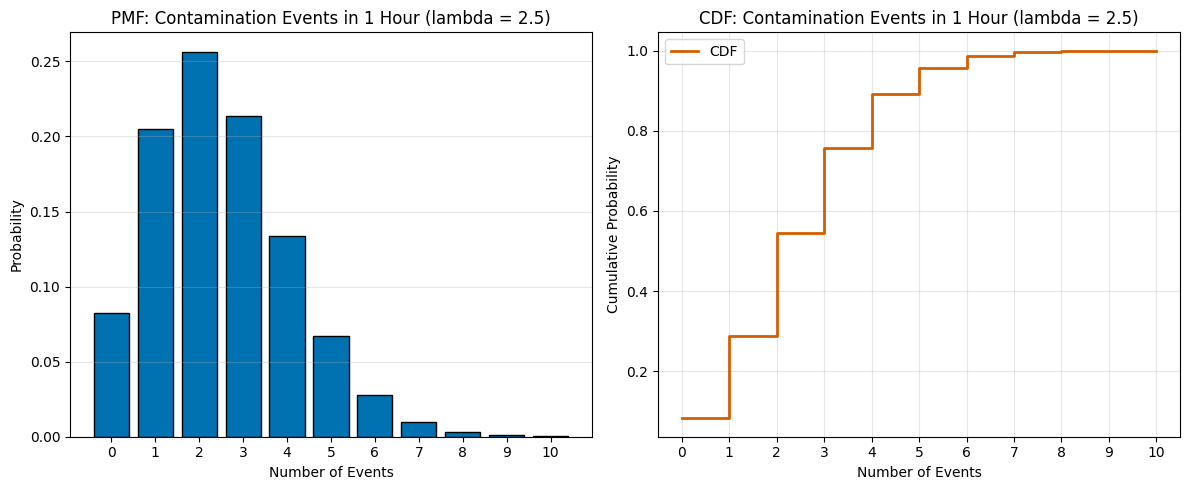

In [ ]:
# Part 2

# import the required libraries as specified by the directions

import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# average rate that is given in the problem
lam = 2.5

# historical data that was given in the problem
historical_data = [2, 3, 1, 4, 2, 3, 2, 1, 3, 2,
                   4, 2, 3, 1, 2, 3, 2, 5, 2, 3,
                   1, 2, 3, 2, 4, 2, 3, 2, 1, 3]

# use numpy (np due to import) to verify the average rate based on the data
print("Historical average rate:", round(np.mean(historical_data), 3))

# loop that finds probablility of 0,1,2,3,4,5 events in 1 hour using imported poisson
print("\n--- Probability of exactly k events in 1 hour ---")
for k in range(6):
    print(f"P(X = {k}) = {poisson.pmf(k, lam):.4f}")

# Probability of more than 4 events in 1 hour, 0 events in 30 mins, and probability of more than 1 hour of cleaning needed.
print("\nP(more than 4 events in 1 hour) =", round(poisson.sf(4, lam), 4))
print("P(0 events in 30 minutes)       =", round(poisson.pmf(0, lam * 0.5), 4))
print("P(>1 hr cleaning in 4-hr shift) =", round(poisson.sf(4, lam * 4), 4))

# set axis and values for graphs
k = np.arange(0, 11)
pmf = poisson.pmf(k, lam)
cdf = poisson.cdf(k, lam)

# create the actual graph display with criteria specified in the assignment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(k, pmf, color="#0072B2", edgecolor="black")
axes[0].set_title("PMF: Contamination Events in 1 Hour (lambda = 2.5)")
axes[0].set_xlabel("Number of Events")
axes[0].set_ylabel("Probability")
axes[0].set_xticks(k)
axes[0].grid(axis="y", alpha=0.3)

axes[1].step(k, cdf, where="post", color="#D55E00", linewidth=2, label="CDF")
axes[1].set_title("CDF: Contamination Events in 1 Hour (lambda = 2.5)")
axes[1].set_xlabel("Number of Events")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_xticks(k)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("part2_visualization.png", dpi=150, bbox_inches="tight")
print("\nSaved part2_visualization.png")


### Part 2 Interpretation

The most likely number of contamination events in one hour is two, with a probability of approximately 25.65%. The probability of more than four contamination events in one hour is approximately 10.88%.

There is approximately a 28.65% probability of having no contamination events during a 30-minute period. Over a four-hour shift, there is approximately a 97.07% probability that contamination events will require more than one hour of total cleaning time.

## Part 3 - Chip Testing Until Failure

This scenario follows a geometric distribution because chips are tested independently until the first failure occurs. Each chip has the same probability of failure, equal to 0.15, and testing continues until that first failure is observed.

The analysis determines the probability that the first failure occurs on tests 1 through 5, the probability that more than 10 chips must be tested, the expected number of tests until failure, and the expected testing cost.

--- Probability of first failure on test k ---
P(X = 1) = 0.1500
P(X = 2) = 0.1275
P(X = 3) = 0.1084
P(X = 4) = 0.0921
P(X = 5) = 0.0783

P(more than 10 tests) = 0.1969
Expected number of tests = 6.6667
Expected testing cost = $333.33


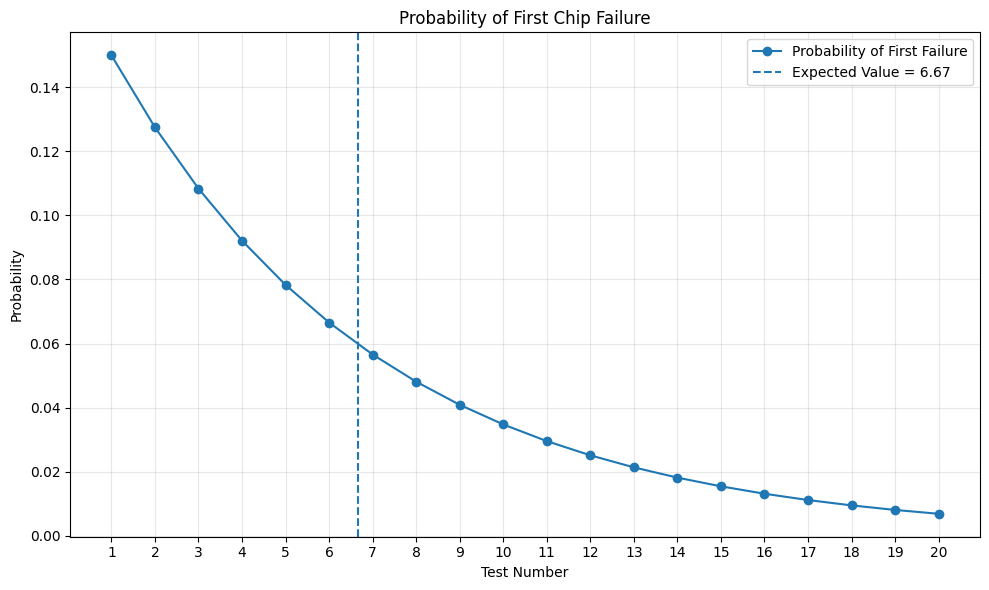


Saved part3_visualization.png


In [ ]:
# Part 3 - Chip Testing Until Failure

# import required libraries
import numpy as np
from scipy.stats import geom
import matplotlib.pyplot as plt

# probability values
pass_probability = 0.85
failure_probability = 1 - pass_probability

p = failure_probability

print("--- Probability of first failure on test k ---")

# probability first failure occurs on tests 1 through 5
for k in range(1, 6):
    probability = geom.pmf(k, p)
    print(f"P(X = {k}) = {probability:.4f}")

# probability more than 10 chips are tested before failure
prob_more_than_10 = geom.sf(10, p)

# expected number of tests
expected_tests = 1 / p

# expected cost
cost_per_chip = 50
expected_cost = expected_tests * cost_per_chip

print("\nP(more than 10 tests) =", round(prob_more_than_10, 4))
print("Expected number of tests =", round(expected_tests, 4))
print("Expected testing cost = $" + f"{expected_cost:.2f}")

# probabilities for tests 1 through 20
tests = np.arange(1, 21)
probabilities = geom.pmf(tests, p)

plt.figure(figsize=(10, 6))

plt.plot(
    tests,
    probabilities,
    marker="o",
    label="Probability of First Failure"
)

# vertical line at expected value
plt.axvline(
    expected_tests,
    linestyle="--",
    label=f"Expected Value = {expected_tests:.2f}"
)

plt.title("Probability of First Chip Failure")
plt.xlabel("Test Number")
plt.ylabel("Probability")
plt.xticks(tests)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("part3_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved part3_visualization.png")

### Part 3 Interpretation

The probability of finding a failure decreases as the test number increases because each additional test requires all previous chips to have passed. The probability that more than 10 chips must be tested before finding a failure is approximately 19.69%.

On average, the first failure is expected after approximately 6.67 tests. At a testing cost of 50.00 dollars per chip, the expected cost to identify the first failure is approximately 333.33 dollars.

## Part 4 - Multi-Stage Production Line

This scenario is more complex than a standard binomial model because all five inspection stations are independent but have different probabilities of detecting a defect. A traditional binomial distribution assumes the same probability of success for every trial.

Because the station probabilities differ, a Monte Carlo simulation of 10,000 defective chips is used to estimate the probability distribution of the number of stations that detect each defect.

--- Empirical probability distribution ---
P(1 stations detect) = 0.0004
P(2 stations detect) = 0.0043
P(3 stations detect) = 0.0528
P(4 stations detect) = 0.2992
P(5 stations detect) = 0.6433

P(at least 3 stations detect) = 0.9953
Expected stations detecting   = 4.5807

Saved part4_visualization.png


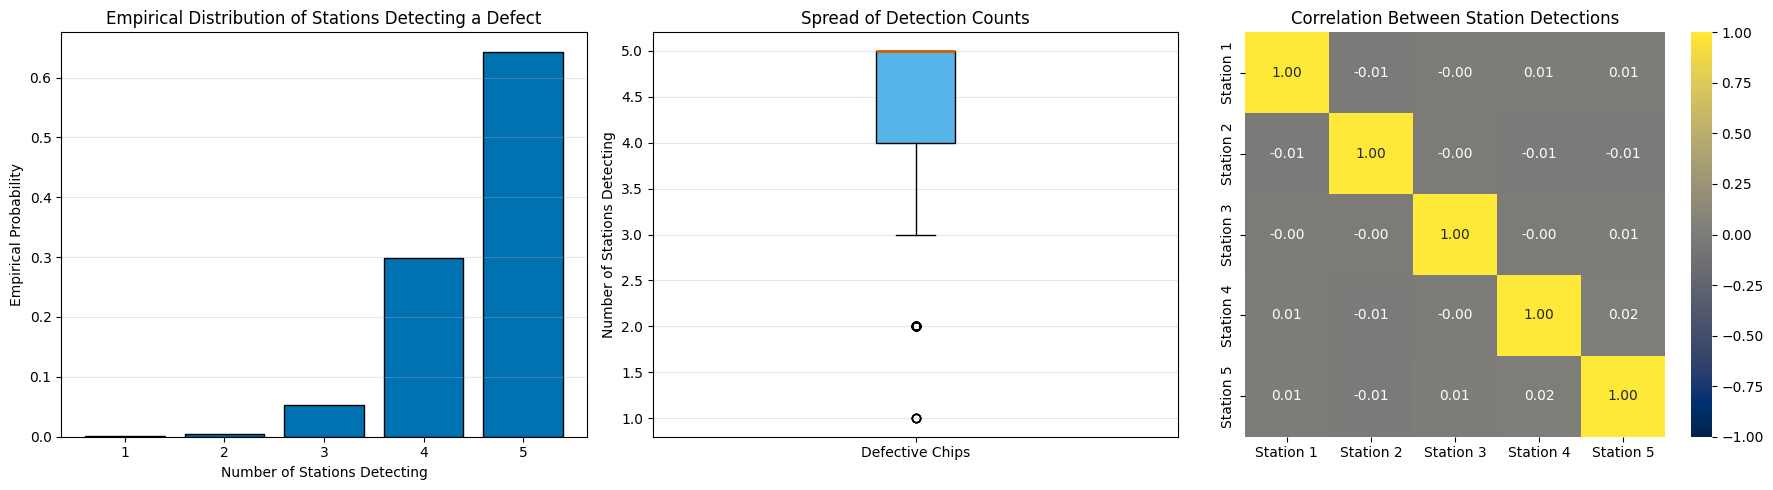

In [ ]:
# Part 4

# import the required libraries as specified by the directions
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# create function with the simulation count, detection probability per station
def simulate_production_line(n_simulations=10000):
    # detection probabilities
    detection_probs = [0.95, 0.92, 0.88, 0.90, 0.93]
    # create grid of random numbers
    random_values = np.random.random((n_simulations, len(detection_probs)))
    # determine if there was a detection and store 1 or 0
    station_detections = (random_values < detection_probs).astype(int)
    # count detections
    detection_counts = station_detections.sum(axis=1)
    return detection_counts, station_detections

detection_counts, station_detections = simulate_production_line()

# list distinct counts and how often they occured
values, counts = np.unique(detection_counts, return_counts=True)
empirical_probs = counts / len(detection_counts)

# list the detections and assignment deliverables
print("--- Empirical probability distribution ---")
for v, p in zip(values, empirical_probs):
    print(f"P({v} stations detect) = {p:.4f}")

print("\nP(at least 3 stations detect) =", round(np.mean(detection_counts >= 3), 4))
print("Expected stations detecting   =", round(np.mean(detection_counts), 4))

# create the visual for the assignment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(values, empirical_probs, color="#0072B2", edgecolor="black")
axes[0].set_title("Empirical Distribution of Stations Detecting a Defect")
axes[0].set_xlabel("Number of Stations Detecting")
axes[0].set_ylabel("Empirical Probability")
axes[0].set_xticks(values)
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(detection_counts, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#56B4E9"),
                medianprops=dict(color="#D55E00", linewidth=2))
axes[1].set_title("Spread of Detection Counts")
axes[1].set_ylabel("Number of Stations Detecting")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Defective Chips"])
axes[1].grid(axis="y", alpha=0.3)

labels = [f"Station {i}" for i in range(1, 6)]
corr = np.corrcoef(station_detections.T)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="cividis", ax=axes[2],
            xticklabels=labels, yticklabels=labels, vmin=-1, vmax=1)
axes[2].set_title("Correlation Between Station Detections")

plt.tight_layout()
plt.savefig("part4_visualization.png", dpi=150, bbox_inches="tight")
print("\nSaved part4_visualization.png")

### Part 4 Interpretation

The simulation shows that most defective chips are detected by either four or five inspection stations. Approximately 64.33% of chips were detected by all five stations, while approximately 29.92% were detected by four stations.

The probability that at least three stations detect a defect was approximately 99.53%. The average number of detecting stations was approximately 4.58 out of 5.

The correlation heatmap shows values close to zero between different stations, which is consistent with the assumption that station detections are independent.